# Electricity Price & Production Analysis

Weather, Production, and Market Structure

### 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import glob
import os

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

#### 1.1 Functions

In [2]:
def normalize_datetime(df, colname):
    """Converts a datetime column to a UTC datetime column."""
    df = df.rename(columns={colname: 'datetime'})
    df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
    return df


def calculate_dk_area(row, area_column, area_type):
    """Calculates the dk area for a given column."""
    try:
        if area_type == 'area':
            return str(row[area_column])[6]
        elif area_type == 'municipality':
            return "1" if int(row[area_column]) > 400 else "2"
        elif area_type == 'longitude':
            val = row[area_column]
            if pd.isnull(val):
                return None
            try:
                val = float(val)
                return '1' if val < 11 else '2'
            except ValueError:
                return None
    except Exception:
        return None

#### 1.2 Municipality Dataset

Used to assign the correct municipalities to the datasets containing weather stations

In [3]:
# Load the municipality coordinates dataset
municipality_to_coordinates = pd.read_csv('municipality_codes_to_coordinates.csv')
municipality_coords = municipality_to_coordinates[['latitude', 'longitude']].to_numpy()
municipality_codes = municipality_to_coordinates['code'].to_numpy()


def calculate_municipality_code(row):
    try:
        lat = row['latitude']
        lon = row['longitude']
        if pd.isnull(lat) or pd.isnull(lon):
            return None

        input_coord = np.array([lat, lon])

        # Compute squared Euclidean distances
        distances = np.sum((municipality_coords - input_coord) ** 2, axis=1)

        # Find the index of the closest municipality
        closest_idx = np.argmin(distances)

        return municipality_codes[closest_idx]

    except Exception:
        return None

### 2. Data Loading & Basic Preparation

#### 2.1 Day Ahead Prices

In [4]:
csv_files = glob.glob(os.path.join('DayAheadPrices', '*.csv'))
day_ahead = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
day_ahead = day_ahead.drop(columns=['Intraday Period (UTC)', 'Intraday Price (EUR/MWh)'])

day_ahead['MTU (UTC)'] = day_ahead['MTU (UTC)'].str.split(' - ').str[1]
day_ahead['MTU (UTC)'] = pd.to_datetime(day_ahead['MTU (UTC)'], format='%d/%m/%Y %H:%M:%S', utc=True)
day_ahead['CalculatedDKArea'] = day_ahead.apply(lambda row: calculate_dk_area(row, 'Area', 'area'), axis=1)

display(day_ahead)

,MTU (UTC),Area,Sequence,Day-ahead Price (EUR/MWh),CalculatedDKArea
0,2021-01-01 00:00:00+00:00,BZN|DK1,Without Sequence,50.87,1
1,2021-01-01 01:00:00+00:00,BZN|DK1,Without Sequence,48.19,1
2,2021-01-01 02:00:00+00:00,BZN|DK1,Without Sequence,44.68,1
3,2021-01-01 03:00:00+00:00,BZN|DK1,Without Sequence,42.92,1
4,2021-01-01 04:00:00+00:00,BZN|DK1,Without Sequence,40.39,1
...,...,...,...,...,...
82601,2025-09-17 18:00:00+00:00,BZN|DK2,Without Sequence,130.82,2
82602,2025-09-17 19:00:00+00:00,BZN|DK2,Without Sequence,119.35,2
82603,2025-09-17 20:00:00+00:00,BZN|DK2,Without Sequence,90.81,2
82604,2025-09-17 21:00:00+00:00,BZN|DK2,Without Sequence,76.18,2


#### 2.2 Consumption

In [5]:
csv_files = glob.glob(os.path.join('dmi/datasets/Consumption data in months', '*.csv'))
consumption = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
consumption['TimeUTC'] = pd.to_datetime(consumption['TimeUTC'], format='%Y-%m-%dT%H:%M:%S')
consumption['TimeUTC'] = consumption['TimeUTC'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
consumption['CalculatedDKArea'] = consumption.apply(
    lambda row: calculate_dk_area(row, 'MunicipalityCode', 'municipality'), axis=1)

display(consumption)

,ConsumptionkWh,HeatingCategory,HousingCategory,Municipality,MunicipalityCode,RegionName,TimeDK,TimeUTC,CalculatedDKArea
0,1902.440,Andet,Andet,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
1,17.150,Elvarme eller varmepumpe,Andet,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
2,34816.125,Andet,Etageejendom,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
3,220.740,Elvarme eller varmepumpe,Etageejendom,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
4,206.520,Andet,Fritidshuse,København,101,Region Hovedstaden,2022-09-30T23:00:00,2022-09-30T21:00:00Z,2
...,...,...,...,...,...,...,...,...,...
16473330,52.652,Elvarme eller varmepumpe,Etageejendom,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1
16473331,121.220,Andet,Fritidshuse,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1
16473332,1394.092,Elvarme eller varmepumpe,Fritidshuse,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1
16473333,8713.867,Andet,Parcel- og rækkehuse,Hjørring,860,Region Nordjylland,2025-10-01T00:00:00,2025-09-30T22:00:00Z,1


#### 2.3 Sunlight

In [6]:
stations = pd.read_csv('dmi/datasets/dmi_sunlight_stations.csv', delimiter=',')

csv_files = glob.glob(os.path.join('dmi/datasets', '*radiation.csv'))
sunlight = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

# Force timezone UTC
sunlight['timeObserved'] = pd.to_datetime(sunlight['timeObserved'], format='mixed', utc=True)

# Convert to ISO 8601 with Z suffix
sunlight['timeObserved'] = sunlight['timeObserved'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')

# Remove duplicates
sunlight = sunlight.drop_duplicates(subset=['timeObserved', 'stationId'], keep='first')

sunlight = sunlight.merge(stations[['station_id', 'latitude', 'longitude']],
                          left_on='stationId',
                          right_on='station_id',
                          how='left')

sunlight['CalculatedDKArea'] = sunlight.apply(lambda row: calculate_dk_area(row, 'longitude', 'longitude'), axis=1)
sunlight['MunicipalityCode'] = sunlight.apply(lambda row: calculate_municipality_code(row), axis=1)

sunlight = sunlight.rename(
    columns={'latitude': 'sun_latitude', 'longitude': 'sun_longitude', 'stationId': 'sun_station_id'})
sunlight = sunlight.drop(columns=['station_id'])

display(sunlight)

,timeObserved,sun_station_id,stationName,mean_radiation,direct_solar_exposure,sun_latitude,sun_longitude,CalculatedDKArea,MunicipalityCode
0,2020-01-01T00:00:00Z,6019,Silstrup,0.0,NaN,56.9300,8.6412,1,787
1,2020-01-01T01:00:00Z,6019,Silstrup,0.0,NaN,56.9300,8.6412,1,787
2,2020-01-01T02:00:00Z,6019,Silstrup,0.0,NaN,56.9300,8.6412,1,787
3,2020-01-01T03:00:00Z,6019,Silstrup,0.0,NaN,56.9300,8.6412,1,787
4,2020-01-01T04:00:00Z,6019,Silstrup,0.0,NaN,56.9300,8.6412,1,787
...,...,...,...,...,...,...,...,...,...
1425195,2025-10-22T06:00:00Z,6197,Nexø Vest,17.0,NaN,55.0557,15.0953,2,400
1425196,2025-10-22T07:00:00Z,6197,Nexø Vest,54.0,NaN,55.0557,15.0953,2,400
1425197,2025-10-22T08:00:00Z,6197,Nexø Vest,176.0,NaN,55.0557,15.0953,2,400
1425198,2025-10-22T09:00:00Z,6197,Nexø Vest,214.0,NaN,55.0557,15.0953,2,400


#### 2.4 Wind

In [7]:
stations = pd.read_csv('dmi/datasets/dmi_wind_stations.csv', delimiter=',')

csv_files = glob.glob(os.path.join('dmi/datasets', '*wind.csv'))
wind = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

wind['timeObserved'] = pd.to_datetime(wind['timeObserved'], format='mixed', utc=True)

# Convert to ISO 8601 with Z suffix
wind['timeObserved'] = wind['timeObserved'].dt.strftime('%Y-%m-%dT%H:%M:%SZ')
# Remove duplicates
wind = wind.drop_duplicates(subset=['timeObserved', 'stationId'], keep='first')

wind = wind.merge(stations[['station_id', 'latitude', 'longitude']],
                  left_on='stationId',
                  right_on='station_id',
                  how='left')

wind["CalculatedDKArea"] = wind.apply(lambda row: calculate_dk_area(row, "longitude", "longitude"), axis=1)
wind['MunicipalityCode'] = wind.apply(lambda row: calculate_municipality_code(row), axis=1)

wind = wind.rename(
    columns={'latitude': 'wind_latitude', 'longitude': 'wind_longitude', 'stationId': 'wind_station_id'})
wind = wind.drop(columns=['station_id'])

display(wind)

,timeObserved,wind_station_id,stationName,mean_wind_speed,wind_latitude,wind_longitude,CalculatedDKArea,MunicipalityCode
0,2020-01-01T00:00:00Z,6019,Silstrup,6.3,56.9300,8.6412,1,787
1,2020-01-01T01:00:00Z,6019,Silstrup,7.0,56.9300,8.6412,1,787
2,2020-01-01T02:00:00Z,6019,Silstrup,8.2,56.9300,8.6412,1,787
3,2020-01-01T03:00:00Z,6019,Silstrup,8.0,56.9300,8.6412,1,787
4,2020-01-01T04:00:00Z,6019,Silstrup,8.6,56.9300,8.6412,1,787
...,...,...,...,...,...,...,...,...
2422252,2024-12-31T20:00:00Z,6197,Nexø Vest,9.3,55.0557,15.0953,2,400
2422253,2024-12-31T21:00:00Z,6197,Nexø Vest,10.4,55.0557,15.0953,2,400
2422254,2024-12-31T22:00:00Z,6197,Nexø Vest,10.6,55.0557,15.0953,2,400
2422255,2024-12-31T23:00:00Z,6197,Nexø Vest,11.3,55.0557,15.0953,2,400


#### 2.5 Merging the datasets

In [9]:
# Normalize datetimes
day_ahead = normalize_datetime(day_ahead, 'MTU (UTC)')
consumption = normalize_datetime(consumption, 'TimeUTC')
sunlight = normalize_datetime(sunlight, 'timeObserved')
wind = normalize_datetime(wind, 'timeObserved')

consumption = (
    consumption.groupby(["datetime", "MunicipalityCode"], as_index=False)
    .agg({
        "ConsumptionkWh": "sum",
        "TimeDK": "first",
        "Municipality": "first",
        "RegionName": "first",
        "CalculatedDKArea": "first"
    })
)

dfs = [day_ahead, consumption, sunlight, wind]

# Make sure datetime is uniform
for i in range(len(dfs)):
    dfs[i]["datetime"] = pd.to_datetime(dfs[i]["datetime"], utc=True)

    # Ensure all required columns exist
    for col in ["CalculatedDKArea", "MunicipalityCode"]:
        if col not in dfs[i].columns:
            dfs[i][col] = None  # or a sensible default
    dfs[i] = dfs[i].set_index(["datetime", "CalculatedDKArea", "MunicipalityCode"])

# Outer-join all datasets by aligning on the MultiIndex
merged = dfs[0]
for dataframe in dfs[1:]:
    merged = merged.join(dataframe, how="outer", rsuffix="_other")

# Bring keys back as columns
merged = merged.reset_index()

# Fill missing data if needed
merged = merged.ffill()

merged = merged.dropna(subset=['mean_wind_speed', 'ConsumptionkWh'])

#### 2.6 Calculating Production
##### 2.6.1 Preparing Data

In [10]:
solar = pd.read_csv('productionData/solar_panels.csv', delimiter=',')
solar.sort_values(by=['kommune'], inplace=True)
solar = solar.drop(columns=['kw_smaa', 'kw_mellem', 'kw_store', 'anl_total', 'anl_smaa', 'anl_mellem', 'anl_store'])

windmills = pd.read_csv('productionData/windmills.csv', delimiter=',')
windmills = windmills.drop(columns=['Shortest distance', 'Average distance', 'Longest distance', 'Inhabitants'])
for city, code in municipality_to_coordinates[['name', 'code']].values:
    windmills.loc[windmills['Kommune'] == city, 'code'] = code
windmills['code'] = windmills['code'].astype(int)

##### 2.6.2 Calculating the production

In [11]:
def wind_cf(v):
    """Returns the wind production capacity factor for a given wind speed."""
    if v < 3: return 0
    elif v < 4: return 0.05
    elif v < 5: return 0.12
    elif v < 6: return 0.22
    elif v < 7: return 0.35
    elif v < 8: return 0.50
    elif v < 9: return 0.65
    elif v < 10: return 0.80
    elif v < 12: return 0.95
    elif v < 25: return 0.90
    else: return 0

# Vectorize it
wind_cf_vec = np.vectorize(wind_cf)

# Add capacities for the rows that don't have any data
solar_lookup = solar.set_index("komnr")["kw_total"]
wind_lookup = windmills.set_index("code")["Installed capacity [kW]"]
merged["pv_kw"] = merged["MunicipalityCode"].map(solar_lookup).fillna(0)
merged["wind_kw"] = merged["MunicipalityCode"].map(wind_lookup).fillna(0)
merged['wind_kw'] = merged['wind_kw'].astype(int)

# Wind output
merged['wind_cf'] = wind_cf_vec(merged['mean_wind_speed'])
merged['wind_kw_out'] = merged['wind_kw'] * merged['wind_cf']

# Solar output
merged["pv_kwh"] = merged["pv_kw"] * (merged["mean_radiation"] / 1000.0) * 0.15

merged["total_kwh"] = merged["pv_kwh"] + merged["wind_kw_out"]

display(merged)

,datetime,CalculatedDKArea,MunicipalityCode,Area,Sequence,Day-ahead Price (EUR/MWh),ConsumptionkWh,TimeDK,Municipality,RegionName,...,stationName_other,mean_wind_speed,wind_latitude,wind_longitude,pv_kw,wind_kw,wind_cf,wind_kw_out,pv_kwh,total_kwh
1527569,2022-08-31 22:00:00+00:00,1,410.0,BZN|DK2,Without Sequence,563.52,5167.720,2022-09-01T00:00:00,Middelfart,Region Syddanmark,...,Langø,4.1,54.8205,10.9939,31151,13470,0.12,1616.4,0.00000,1616.40000
1527570,2022-08-31 22:00:00+00:00,1,420.0,BZN|DK2,Without Sequence,563.52,4988.801,2022-09-01T00:00:00,Assens,Region Syddanmark,...,Assens/Torø,4.0,55.2444,9.8882,63453,31025,0.12,3723.0,0.00000,3723.00000
1527571,2022-08-31 22:00:00+00:00,1,430.0,BZN|DK2,Without Sequence,563.52,6297.272,2022-09-01T00:00:00,Faaborg-Midtfyn,Region Syddanmark,...,Assens/Torø,4.0,55.2444,9.8882,16685,16480,0.12,1977.6,0.00000,1977.60000
1527572,2022-08-31 22:00:00+00:00,1,440.0,BZN|DK2,Without Sequence,563.52,2812.977,2022-09-01T00:00:00,Kerteminde,Region Syddanmark,...,Assens/Torø,4.0,55.2444,9.8882,5828,24950,0.12,2994.0,0.00000,2994.00000
1527573,2022-08-31 22:00:00+00:00,1,450.0,BZN|DK2,Without Sequence,563.52,3457.081,2022-09-01T00:00:00,Nyborg,Region Syddanmark,...,Assens/Torø,4.0,55.2444,9.8882,7064,28980,0.12,3477.6,0.00000,3477.60000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4589305,2025-10-22 10:00:00+00:00,2,360.0,BZN|DK2,Without Sequence,59.92,7229.772,2025-10-07T02:00:00,Bornholms Region,Region Hovedstaden,...,Anholt Havn,14.8,56.7169,11.5098,301334,275045,0.90,247540.5,4248.80940,251789.30940
4589306,2025-10-22 10:00:00+00:00,2,376.0,BZN|DK2,Without Sequence,59.92,7229.772,2025-10-07T02:00:00,Bornholms Region,Region Hovedstaden,...,Anholt Havn,14.8,56.7169,11.5098,56710,58395,0.90,52555.5,1803.37800,54358.87800
4589307,2025-10-22 10:00:00+00:00,2,400.0,BZN|DK2,Without Sequence,59.92,7229.772,2025-10-07T02:00:00,Bornholms Region,Region Hovedstaden,...,Anholt Havn,14.8,56.7169,11.5098,31015,36580,0.90,32922.0,1623.63525,34545.63525
4589308,2025-10-22 10:00:00+00:00,2,400.0,BZN|DK2,Without Sequence,59.92,7229.772,2025-10-07T02:00:00,Bornholms Region,Region Hovedstaden,...,Anholt Havn,14.8,56.7169,11.5098,31015,36580,0.90,32922.0,1712.02800,34634.02800


In [12]:
df = merged.copy()

df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)

### 3. Time-Based Features (used throughout)

In [13]:
df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["is_weekend"] = df["dayofweek"] >= 5

### 4. Correlation Matrix

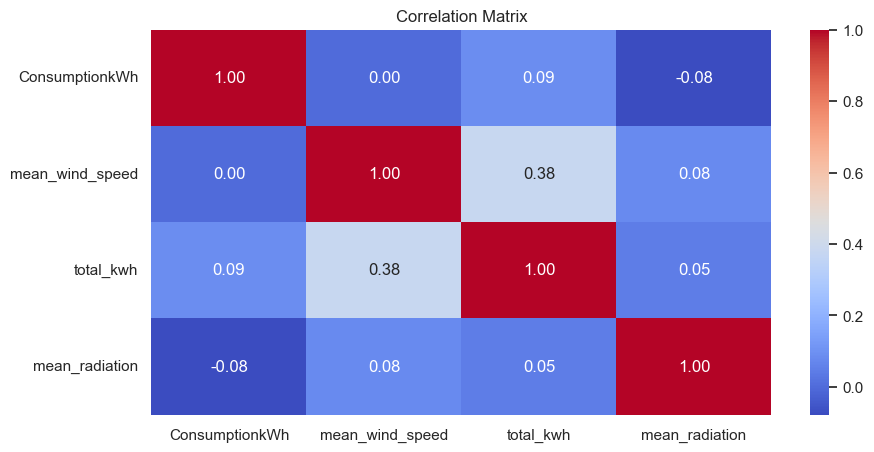

In [15]:
correlation_matrix = df[['ConsumptionkWh', 'mean_wind_speed', 'total_kwh', 'mean_radiation']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()

## Layer 1 — Physical System: Energy Production

Goal: Understand how weather drives production
Prices are not used here

### Weather → Production Relationships
#### 4.1 PV Production vs Sunshine

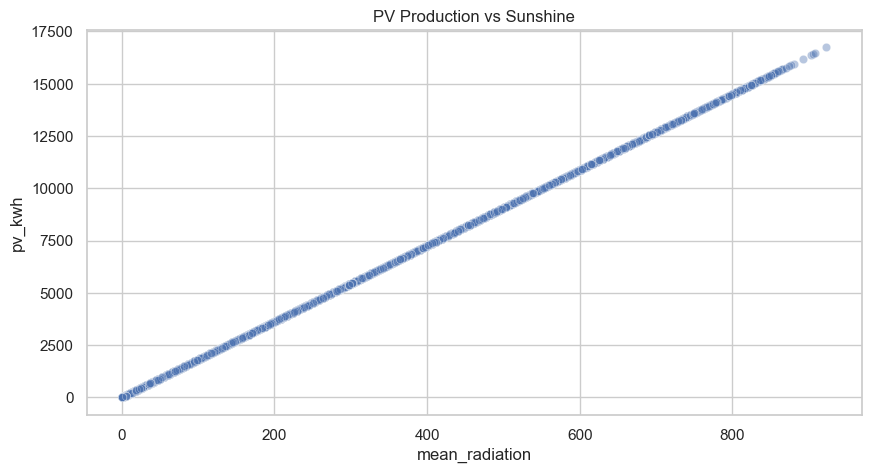

In [17]:
odense_df = df[df['MunicipalityCode'] == 461]
sns.scatterplot(
    data=odense_df,
    x="mean_radiation",
    y="pv_kwh",
    alpha=0.4
)
plt.title("PV Production vs Sunshine")
plt.show()

#### 4.2 Wind Production vs Wind Speed

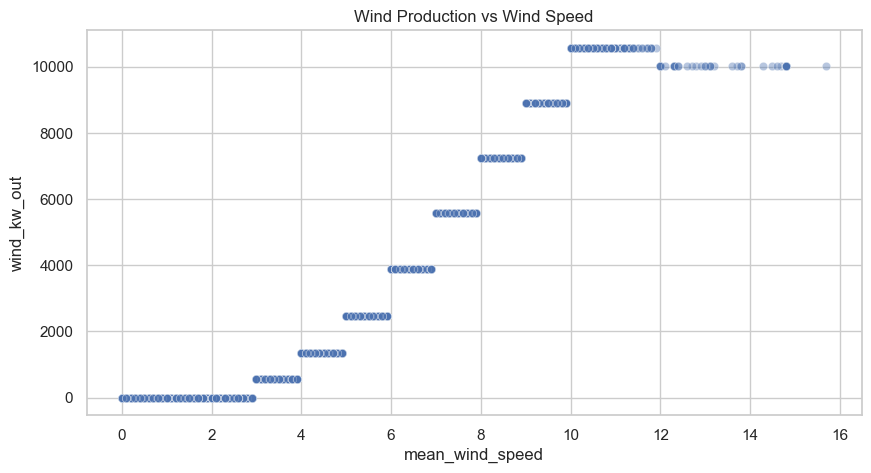

In [18]:
sns.scatterplot(
    data=odense_df,
    x="mean_wind_speed",
    y="wind_kw_out",
    alpha=0.4
)
plt.title("Wind Production vs Wind Speed")
plt.show()

### 5. Production Correlations (Non-Linear)

In [19]:
production_cols = [
    "pv_kwh",
    "wind_kw_out",
    "mean_radiation",
    "mean_wind_speed",
    # "temperature"
]
active_production = df[df['pv_kwh'] > 0]
df[production_cols].corr(method="spearman")

,pv_kwh,wind_kw_out,mean_radiation,mean_wind_speed
pv_kwh,1.000000,0.155374,0.954711,0.086200
wind_kw_out,0.155374,1.000000,0.065649,0.650415
mean_radiation,0.954711,0.065649,1.000000,0.094705
mean_wind_speed,0.086200,0.650415,0.094705,1.000000


Note: Spearman correlation is used to capture monotonic but non-linear relationships.

### 6. Seasonal Structure of Production

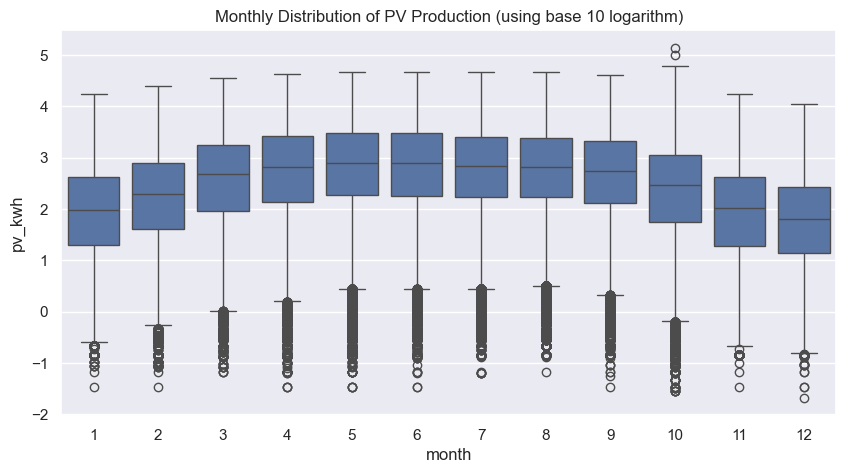

In [20]:
sns.boxplot(
    data=active_production,
    x="month",
    y=np.log10(active_production["pv_kwh"])
)
plt.title("Monthly Distribution of PV Production (using base 10 logarithm)")
plt.show()

## Layer 2 — Market Behavior: Electricity Prices

Goal: Understand price dynamics independent of production**

### 7. Price Overview

In [21]:
df["Day-ahead Price (EUR/MWh)"].describe()

count    3.061741e+06
mean     9.350310e+01
std      8.241821e+01
min     -4.401000e+02
25%      4.729000e+01
50%      8.357000e+01
75%      1.139500e+02
max      9.363100e+02
Name: Day-ahead Price (EUR/MWh), dtype: float64

### 8. Intraday Price Structure

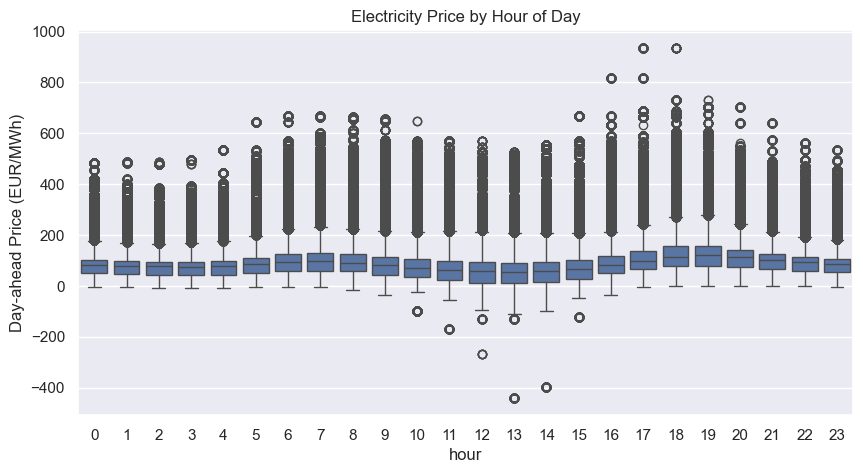

In [22]:
sns.boxplot(
    data=df,
    x="hour",
    y="Day-ahead Price (EUR/MWh)"
)
plt.title("Electricity Price by Hour of Day")
plt.show()

### 9. Weekly & Seasonal Effects

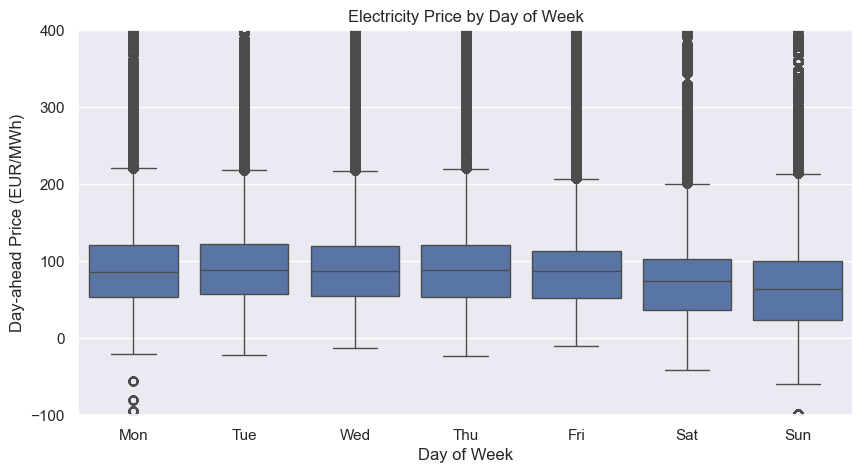

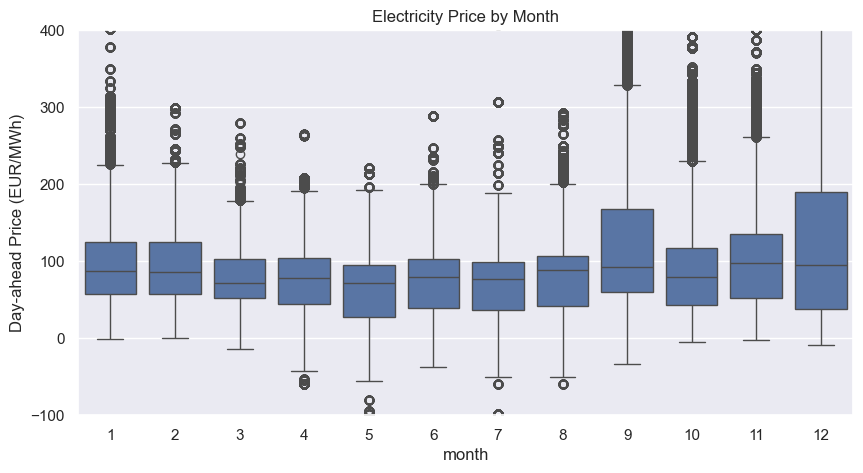

In [28]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
sns.boxplot(
    data=df,
    x="dayofweek",
    y="Day-ahead Price (EUR/MWh)"
)
plt.xticks(ticks=range(7), labels=days)
plt.xlabel("Day of Week")
plt.title("Electricity Price by Day of Week")
plt.ylim(-100, 400)
plt.show()

sns.boxplot(
    data=df,
    x="month",
    y="Day-ahead Price (EUR/MWh)"
)
plt.title("Electricity Price by Month")
plt.ylim(-100, 400)
plt.show()

## Layer 3 — Coupling: Production & Price Interaction

Goal: Understand when production matters for prices**

### 10. Conditional Effects (High Demand Hours)

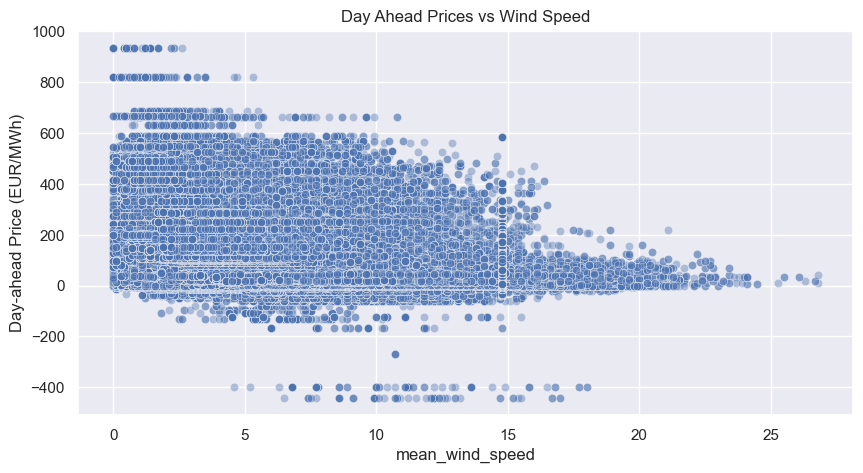

In [24]:
sns.scatterplot(
    data=df[df["hour"].between(11, 17)],
    x="mean_wind_speed",
    y="Day-ahead Price (EUR/MWh)",
    alpha=0.4
)
plt.title("Day Ahead Prices vs Wind Speed")
plt.show()